<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/Text_Classification_with_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install transformers datasets scikit-learn

In [2]:
# Load the dataset
from datasets import load_dataset

emotions = load_dataset("emotion", trust_remote_code=True)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all

In [3]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
# Display the first example from the trainng set
emotions["train"][:5]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy'],
 'label': [0, 0, 3, 2, 3]}

In [5]:
# Convert the Dataset to  Pandas Dataframe
import pandas as pd

# df = emotions["train"].to_pandas()
# df = pd.DataFrame(emotions["train"])
emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head(3)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3


In [6]:
print(type(emotions["train"]))
print(emotions["train"].shape)



<class 'datasets.arrow_dataset.Dataset'>
(16000, 2)


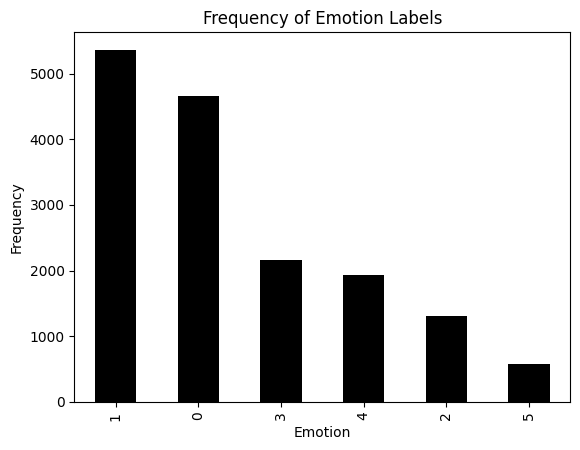

In [7]:
# visualize the data
import matplotlib.pyplot as plt

#plot the distribution of emotion labels
df['label'].value_counts().plot(kind='bar', color = 'black')
plt.title('Frequency of Emotion Labels')
plt.xlabel("Emotion")
plt.ylabel("Frequency")
plt.show()

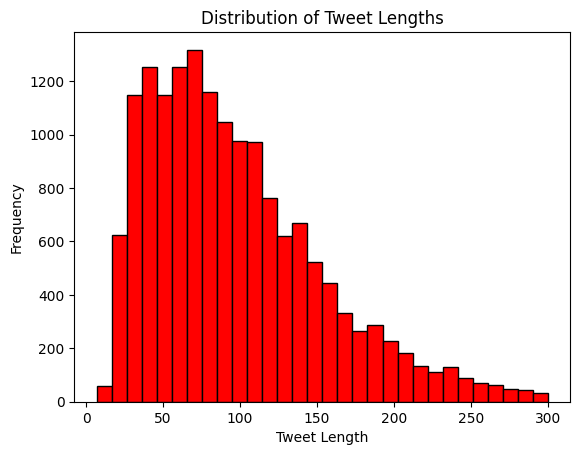

In [8]:
# calculate tweet lengths

df['length'] = df['text'].apply(len)

#plot the distribution of tweet lengths
plt.hist(df['length'], bins=30, color='red', edgecolor='black')
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Tweet Length')
plt.ylabel('Frequency')
plt.show()

In [9]:
# character tokenization example

text = 'hello world!'
tokens = list(text)
print(tokens)

['h', 'e', 'l', 'l', 'o', ' ', 'w', 'o', 'r', 'l', 'd', '!']


In [10]:
# Example of word tokenization
import nltk # Natural Language Toolkit.
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

text = 'hello world!'
tokens = word_tokenize(text)
tokens

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['hello', 'world', '!']

In [11]:
# Example of subword tokenization
from transformers import AutoTokenizer # import the tokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased', force_download=True) # load the tokenizer
# Tokenize sample text
text = "unhappiness"
subword_tokens = tokenizer.tokenize(text)
subword_tokens

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

['un', '##ha', '##pp', '##iness']

In [12]:
# Data processing

#example converting text to token
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
text  = 'Hello, how are you doing today?'
# text1  = 'Hello, Hello Hello Hello Hello Hello?'
tokens = tokenizer.tokenize(text)
tokens

['hello', ',', 'how', 'are', 'you', 'doing', 'today', '?']

In [13]:
# convert token to Ids
input_ids = tokenizer.convert_tokens_to_ids(tokens)
input_ids

[7592, 1010, 2129, 2024, 2017, 2725, 2651, 1029]

In [14]:
# Tokenize with padding and truncation

sentences = ["hello, how are you?", "I am fine, thank you!", "what about you?"]
encoding = tokenizer(sentences, padding=True, truncation=True, return_tensors='pt')#output হবে PyTorch tensor
print((encoding))

{'input_ids': tensor([[ 101, 7592, 1010, 2129, 2024, 2017, 1029,  102,    0],
        [ 101, 1045, 2572, 2986, 1010, 4067, 2017,  999,  102],
        [ 101, 2054, 2055, 2017, 1029,  102,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 0, 0, 0]])}


In [15]:
# Define Tokenization Function
def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True)

# Apply the tokenization Function to the Dataset
from datasets import load_dataset
emotions = load_dataset("emotion")
emotions_encoded = emotions.map(tokenize, batched=True)
print(emotions_encoded['train'][0])

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'text': 'i didnt feel humiliated', 'label': 0, 'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [16]:
emotions["train"][0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [17]:
! pip install datasets transformers

In [18]:
#Example of using Transformers as Feature Extractions
import torch
from transformers import AutoTokenizer, AutoModel

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

#Define the function
def extract_features(text):
  inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
  output = model(**inputs)
  hidden_status = output.last_hidden_state

  #Use the[CLS] token hidden state as the featue representation
  cls_token_features = hidden_status[:, 0, :]
  return cls_token_features.detach().numpy()



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [19]:
text = "Hello, how are you?"
feature = extract_features(text)
feature.shape

(1, 768)

In [20]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [21]:
#  Load the dataset
emotions = load_dataset("emotion")

# Select a smaller subset for training and validation
small_train_dataset = emotions['train'].select(range(512))  # Select first 512 samples for training
small_val_dataset = emotions['validation'].select(range(100))  # Select first 100 samples for validation

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')

# Move model to CPU to manage memory better
device = torch.device("cpu")
model.to(device)

# Define the feature extraction function with torch.no_grad() to save memory
def extract_features(texts):
    with torch.no_grad():
        inputs = tokenizer(
            texts,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=128
        ).to(device)

        outputs = model(**inputs)
        hidden_states = outputs.last_hidden_state

        # CLS token representation
        cls_hidden_state = hidden_states[:, 0, :]

        return cls_hidden_state.cpu().numpy()



# Generator function to process data in smaller batches
def batch_generator(dataset, batch_size=16):
    dataset_size = len(dataset)

    for i in range(0, dataset_size, batch_size):
        end_index = min(i + batch_size, dataset_size)
        batch = dataset.select(range(i, end_index))

        # ✅ CRITICAL FIX: convert to list[str]
        batch_texts = list(batch['text'])
        batch_labels = list(batch['label'])

        batch_features = extract_features(batch_texts)
        yield batch_features, batch_labels

# Function to collect batches
def collect_batches(generator):
    features = []
    labels = []

    for batch_features, batch_labels in generator:
        features.append(batch_features)
        labels.extend(batch_labels)

    return np.vstack(features), np.array(labels)

# Process the smaller dataset using the batch generator
# ================================
train_generator = batch_generator(small_train_dataset, batch_size=16)
X_train, y_train = collect_batches(train_generator)

val_generator = batch_generator(small_val_dataset, batch_size=16)
X_val, y_val = collect_batches(val_generator)


print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train shape: (512, 768) (512,)
Val shape: (100, 768) (100,)


In [22]:
# texts = ["love love love", "This is bad"]

# with torch.no_grad():
#     inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True)
#     outputs = model(**inputs)

# print("input_ids shape:", inputs["input_ids"])
# print("hidden_states shape:", outputs.last_hidden_state.shape)

# cls_vec = outputs.last_hidden_state[:,0,:]
# print("CLS shape:", cls_vec.shape)
# print("CLS first row first 5 values:", cls_vec[0][:5])

In [23]:
# text = "I " * 600

# print(len(tokenizer(text, truncation=False)["input_ids"]))
# print(len(tokenizer(text, truncation=True, max_length=128)["input_ids"]))


In [24]:
# Train the classifier
clf = LogisticRegression(max_iter=3000)
clf.fit(X_train, y_train)

#Evaluate the classifier
y_pred = clf.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print(f"Valudation Accuracy: {accuracy}")

Valudation Accuracy: 0.47


In [25]:
# Install required libraries
!pip install datasets transformers accelerate accelerate -U

In [28]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from datasets import load_dataset

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=6)

emotions = load_dataset("emotion")

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
  return tokenizer(batch["text"], padding=True, truncation=True)

emotions_encoded = emotions.map(tokenize, batched=True)

train_dataset = emotions_encoded['train'].select(range(32))
val_dataset = emotions_encoded['validation'].select(range(16))

train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
val_dataset.set_format("torch")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [29]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    per_device_train_batch_size=4,  # Reduced batch size for initial testing
    per_device_eval_batch_size=4,   # Reduced batch size for initial testing
    num_train_epochs=1,             # Only 1 epoch for initial testing
    weight_decay=0.01,
    logging_dir="./logs",           # Directory for storing logs
    logging_steps=10,               # Log every 10 steps
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [30]:
from transformers import Trainer

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

# Train the model with progress tracking
print("Starting training...")
trainer.train()
print("Training completed.")

# Evaluate the model
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")


Starting training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,No log,1.609833


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training completed.


Evaluation results: {'eval_loss': 1.609832763671875, 'eval_runtime': 9.7321, 'eval_samples_per_second': 1.644, 'eval_steps_per_second': 0.411, 'epoch': 1.0}


In [31]:
# Predict on the validation dataset
predictions = trainer.predict(val_dataset)
y_pred = predictions.predictions.argmax(axis=1)
y_val = predictions.label_ids

# Compute accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.375


In [32]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average='weighted')
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")


Precision: 0.140625
Recall: 0.375
F1-Score: 0.20454545454545453


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


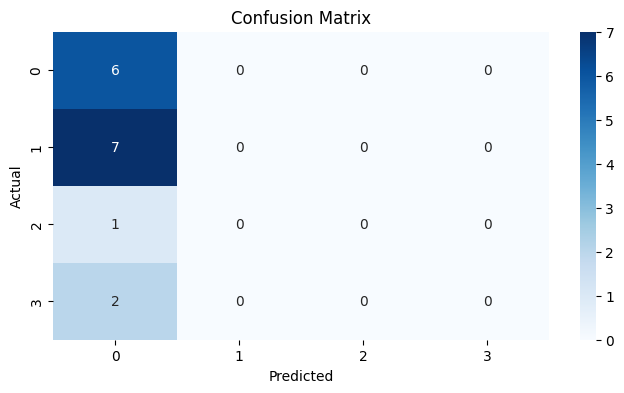

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# TP (True Positive): class-কে সঠিকভাবে predict করা হয়েছে
# FP (False Positive): অন্য class কে ভুল predict করে target class বলা হয়েছে
# FN (False Negative): target class কে অন্য class বলা হয়েছে

# 🔹 Precision (নির্ভুলতা) :এক class predict করা হলে সেটি কতটা সঠিক ছিল তা বোঝায়।
#recall : এক class-এর সত্যিকারের উদাহরণগুলোর মধ্যে কতগুলো সঠিকভাবে predict করা হয়েছে।
# F1 Score:Precision এবং Recall-এর harmonic mean, যা balance করে।